# CSET343 – AI in Healthcare
## Lab Assignment 5: Multiclass Classification

This notebook works through **Task 1 → Task 3 completely on the Dermatology dataset first (Part A)** — loaded from a local CSV file — then **repeats Task 1 → Task 3 completely on the Vertebral dataset (Part B)** — loaded via `ucimlrepo`.


### Setup — Install Required Packages

In [1]:
# Run this cell once to install all required packages
!pip install -q ucimlrepo scikit-learn pandas numpy matplotlib seaborn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


---
---
# PART A: Dermatology Dataset
---
---


## Task 1: Data Acquisition and Exploration — Dermatology

### 1.1 Download and Load the Dataset

In [3]:
# Load the Dermatology dataset directly from the UCI ML Repository via ucimlrepo.
# (Same approach as the Vertebral dataset in Part B — this makes the notebook fully
# portable so it runs on any machine with internet access, without needing a local CSV.)
from ucimlrepo import fetch_ucirepo

dermatology = fetch_ucirepo(id=33)

X_raw = dermatology.data.features
y_raw = dermatology.data.targets

df = pd.concat([X_raw, y_raw], axis=1)

print("Shape:", df.shape)
df.head()


Shape: (366, 35)


,erythema,scaling,definite-borders,itching,koebner phenomenon,polygonal papules,follicular papules,oral-mucosal involvement,knee elbow involvement,scalp involvement,...,disappearance of the granular layer,vacuolisation and damage of the basal layer,spongiosis,saw-tooth appearance of retes,follicular horn plug,perifollicular parakeratosis,inflammatory monoluclear infiltrate,band-like infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


In [4]:
# Identify the target column automatically (handles slightly different column names
# across dataset versions/sources, e.g. 'class', 'Class', 'target')
possible_targets = [c for c in df.columns if c.strip().lower() in ("class", "target", "diagnosis")]
target_col = possible_targets[0] if possible_targets else df.columns[-1]
print("Detected target column:", target_col)

df = df.rename(columns={target_col: "target"})
print("Shape:", df.shape)
df.head()


Detected target column: class
Shape: (366, 35)


,erythema,scaling,definite-borders,itching,koebner phenomenon,polygonal papules,follicular papules,oral-mucosal involvement,knee elbow involvement,scalp involvement,...,disappearance of the granular layer,vacuolisation and damage of the basal layer,spongiosis,saw-tooth appearance of retes,follicular horn plug,perifollicular parakeratosis,inflammatory monoluclear infiltrate,band-like infiltrate,age,target
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   erythema                                     366 non-null    int64  
 1   scaling                                      366 non-null    int64  
 2   definite-borders                             366 non-null    int64  
 3   itching                                      366 non-null    int64  
 4   koebner phenomenon                           366 non-null    int64  
 5   polygonal papules                            366 non-null    int64  
 6   follicular papules                           366 non-null    int64  
 7   oral-mucosal involvement                     366 non-null    int64  
 8   knee elbow involvement                       366 non-null    int64  
 9   scalp involvement                            366 non-null    int64  
 10  fa

### 1.2 Summary Statistics

In [6]:
df.describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.00,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.00,3.0
definite-borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.00,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.00,3.0
koebner phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.00,3.0
polygonal papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.00,3.0
follicular papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.00,3.0
oral-mucosal involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.00,3.0
knee elbow involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.00,3.0
scalp involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.00,3.0


### 1.3 Missing Values, Duplicates, and Outliers

In [7]:
# Some UCI-style datasets encode missing values as '?'
df = df.replace("?", np.nan)

# Try to convert all feature columns to numeric where possible
for col in df.columns:
    if col != "target":
        try:
            df[col] = pd.to_numeric(df[col])
        except (ValueError, TypeError):
            pass

print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing values per column:
 age    8
dtype: int64

Number of duplicate rows: 0


In [8]:
# Handle missing values — impute numeric columns with the median
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Drop exact duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {before - df.shape[0]} duplicate rows")

print("\nRemaining missing values:", df.isnull().sum().sum())


Dropped 0 duplicate rows

Remaining missing values: 0


In [9]:
# Outlier detection using the IQR method (reported per feature, not auto-removed —
# tree/margin-based models used later are fairly robust to a few outliers)
feature_cols = [c for c in numeric_cols if c != "target"]

outlier_counts = {}
for col in feature_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_summary = pd.Series(outlier_counts).sort_values(ascending=False)
outlier_summary


acanthosis                                     156
erythema                                       151
munro microabcess                               80
band-like infiltrate                            77
vacuolisation and damage of the basal layer     72
saw-tooth appearance of retes                   72
focal hypergranulosis                           71
melanin incontinence                            70
spongiform pustule                              70
polygonal papules                               69
oral-mucosal involvement                        67
fibrosis of the papillary dermis                54
family history                                  46
eosinophils in the infiltrate                   42
follicular papules                              33
thinning of the suprapapillary epidermis        31
knee elbow involvement                          23
follicular horn plug                            22
perifollicular parakeratosis                    21
koebner phenomenon             

### 1.4 Visualizations

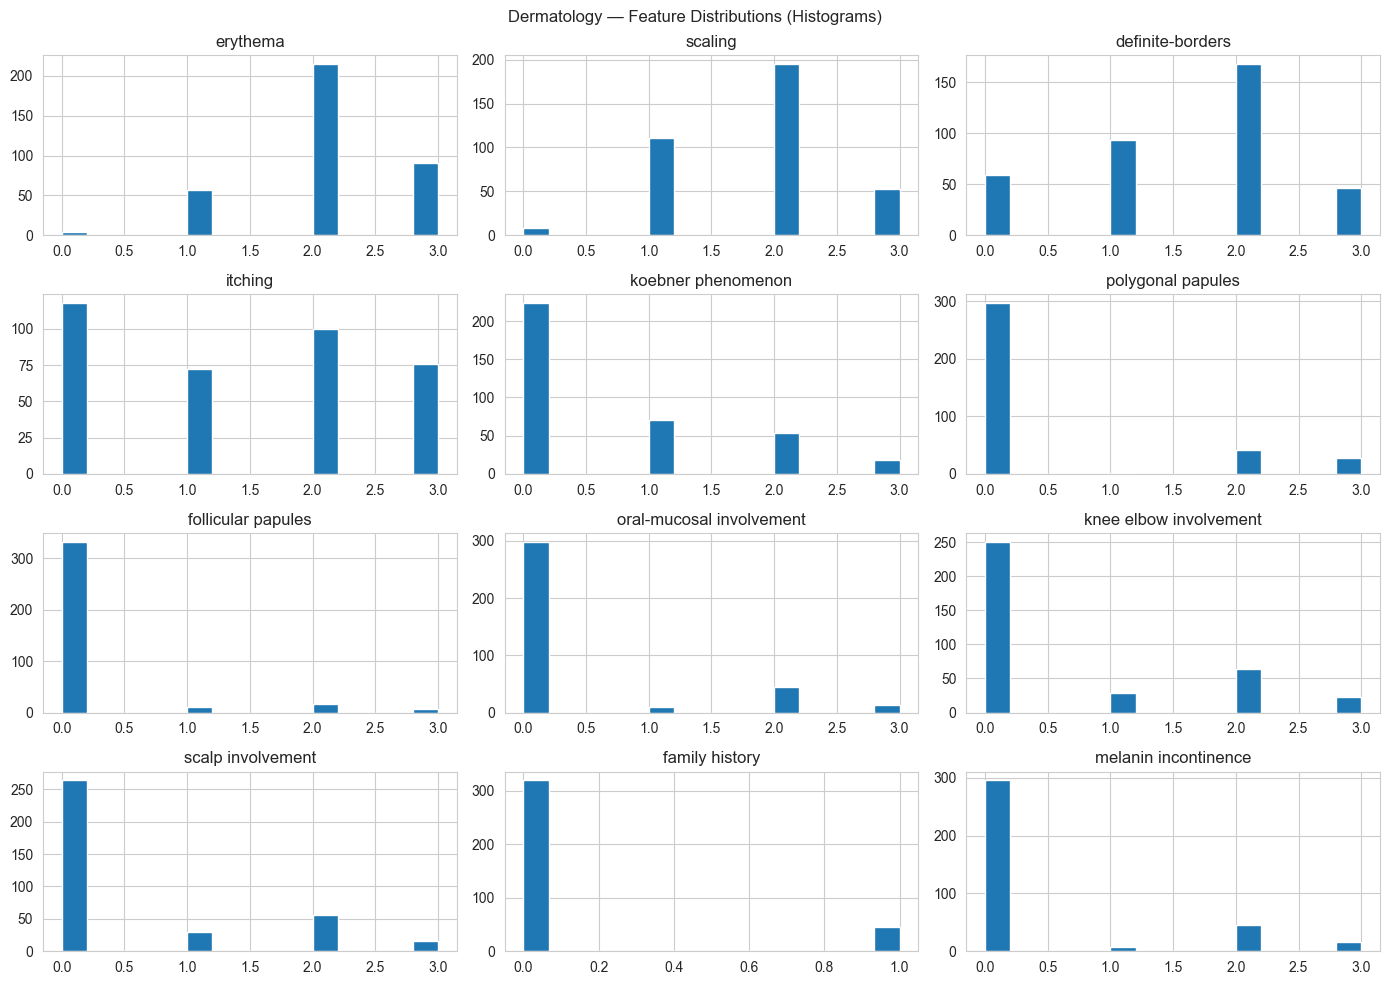

In [10]:
# Histograms for the features (first 12 to keep the plot readable if there are many)
sample_cols = feature_cols[:12]
df[sample_cols].hist(figsize=(14, 10), bins=15)
plt.suptitle("Dermatology — Feature Distributions (Histograms)")
plt.tight_layout()
plt.show()


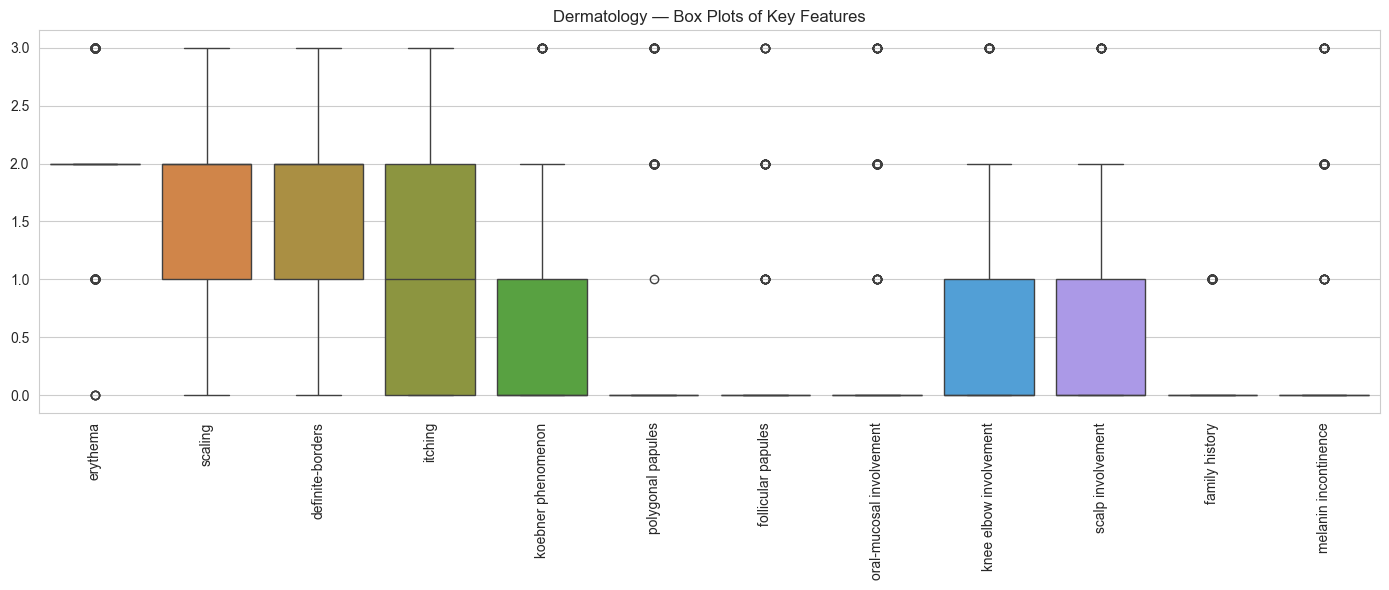

In [11]:
# Box plots for the same features
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[sample_cols])
plt.xticks(rotation=90)
plt.title("Dermatology — Box Plots of Key Features")
plt.tight_layout()
plt.show()


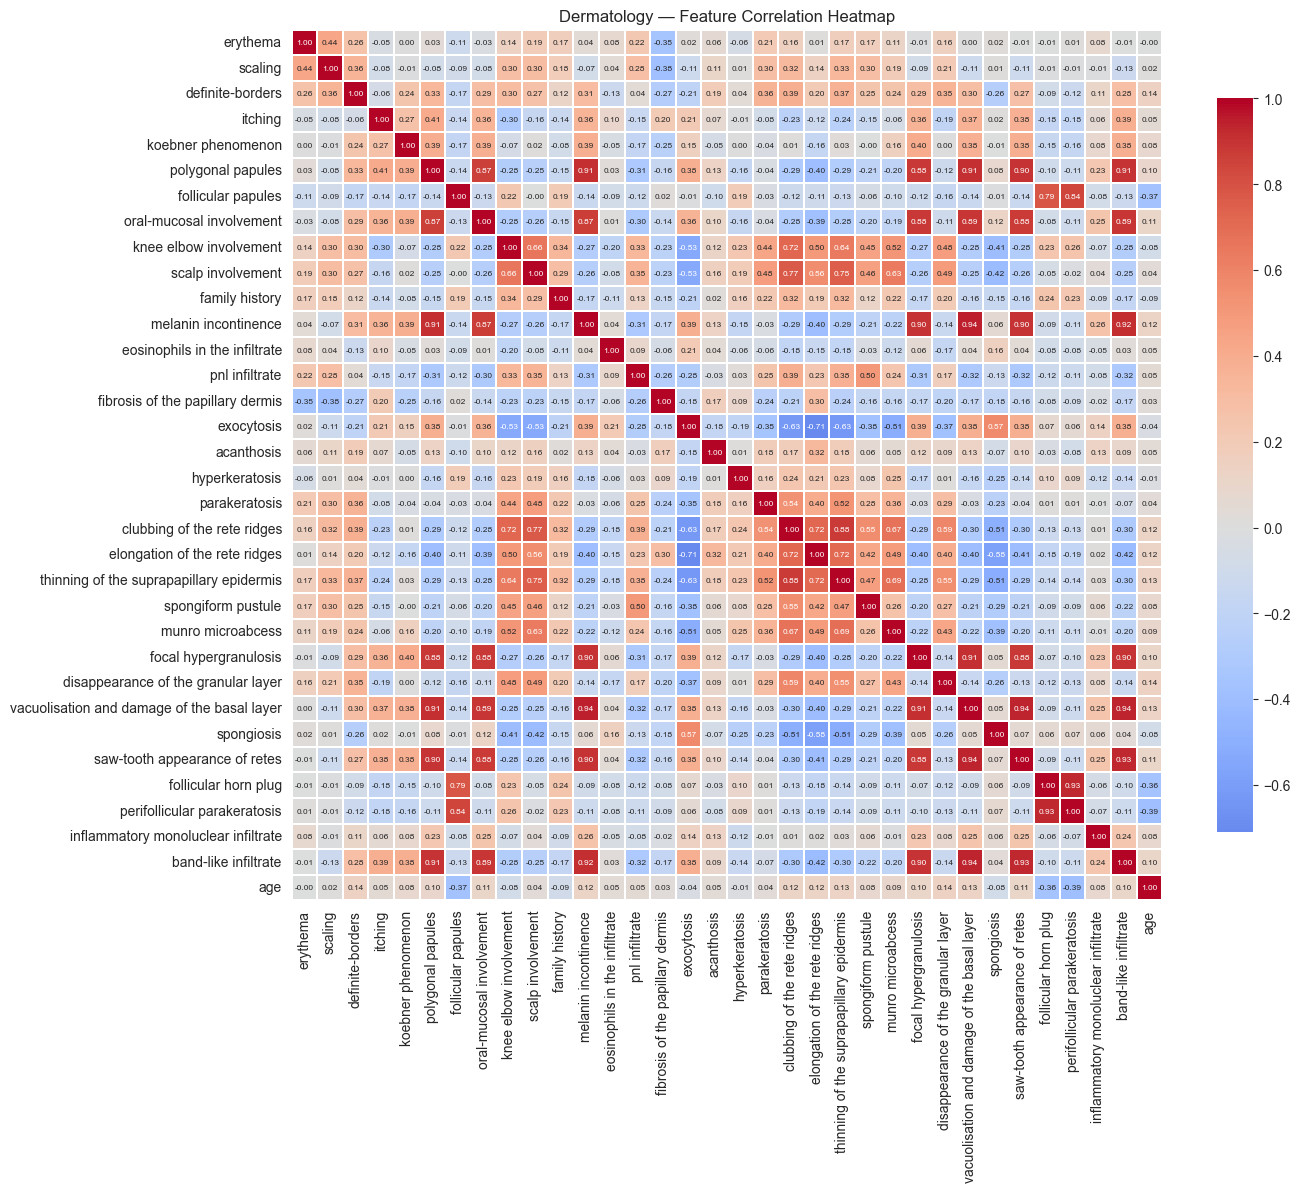

In [12]:
# Correlation heatmap
plt.figure(figsize=(14, 12))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3,
            annot=True, fmt=".2f", annot_kws={"size": 6}, cbar_kws={"shrink": 0.8})
plt.title("Dermatology — Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


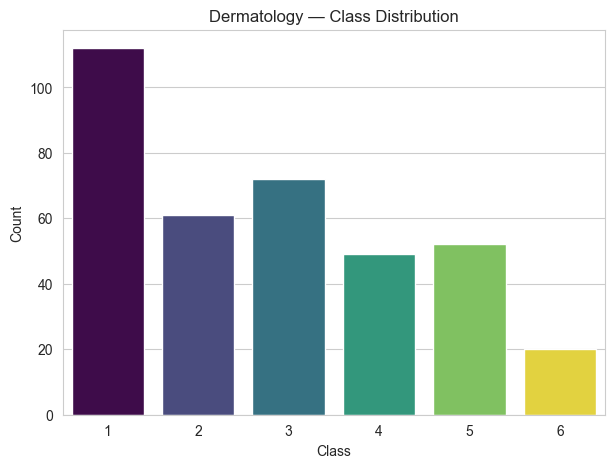

target
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64


In [13]:
# Class distribution
plt.figure(figsize=(7, 5))
sns.countplot(x="target", data=df, hue="target", palette="viridis", legend=False)
plt.title("Dermatology — Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df["target"].value_counts())


**Discussion — Class Imbalance:**
Check the class distribution plot above. If one or more classes have noticeably fewer samples, the classifier can get biased toward the majority class(es), and plain accuracy can look misleadingly high while minority-class recall stays poor. This is why the split below uses **stratified sampling**, and why Task 3 reports **macro-averaged** metrics alongside weighted ones.

## Task 2: Data Preprocessing

### 2.1 Encode the Target Variable

In [14]:
le = LabelEncoder()
df["target_encoded"] = le.fit_transform(df["target"].astype(str))

print("Classes:", list(le.classes_))
X = df[feature_cols].values
y = df["target_encoded"].values


Classes: ['1', '2', '3', '4', '5', '6']


### 2.2 Train/Test Split (Stratified, 80/20)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class balance:\n", pd.Series(y_train).value_counts(normalize=True).sort_index())
print("\nTest class balance:\n", pd.Series(y_test).value_counts(normalize=True).sort_index())


Train shape: (292, 34) Test shape: (74, 34)
Train class balance:
 0    0.304795
1    0.167808
2    0.195205
3    0.133562
4    0.143836
5    0.054795
Name: proportion, dtype: float64

Test class balance:
 0    0.310811
1    0.162162
2    0.202703
3    0.135135
4    0.135135
5    0.054054
Name: proportion, dtype: float64


### 2.3 Feature Standardization

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean of scaled training features (~0):", np.round(X_train_scaled.mean(), 3))
print("Std of scaled training features (~1):", np.round(X_train_scaled.std(), 3))


Mean of scaled training features (~0): -0.0
Std of scaled training features (~1): 1.0


## Task 3: Model Training and Basic Evaluation

### 3.1 Define and Train Multiple Multiclass Models

In [17]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)
    print(f"Trained: {name}")


Trained: KNN
Trained: Logistic Regression
Trained: Random Forest
Trained: SVM (RBF)


/Users/pankurajasaivardhan/Documents/AIH/aih/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/pankurajasaivardhan/Documents/AIH/aih/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/pankurajasaivardhan/Documents/AIH/aih/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/pankurajasaivardhan/Documents/AIH/aih/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/pankurajasaivardhan

Trained: Gradient Boosting


### 3.2 Accuracy, Precision, Recall, F1-score

In [18]:
results = []
for name in models:
    y_pred = predictions[name]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision (weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df


,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted)
Model,,,,,,,
KNN,0.9054,0.9071,0.9094,0.9034,0.9193,0.9054,0.9081
Logistic Regression,0.9595,0.9615,0.9611,0.9574,0.9688,0.9595,0.9606
Random Forest,0.9595,0.9545,0.9556,0.9545,0.9607,0.9595,0.9595
SVM (RBF),0.9730,0.9722,0.9722,0.9697,0.9775,0.9730,0.9730
Gradient Boosting,0.9324,0.9062,0.9250,0.9125,0.9333,0.9324,0.9309


In [19]:
# Detailed per-class report for each model
for name in models:
    print(f"\n===== {name} — Classification Report =====")
    print(classification_report(y_test, predictions[name], target_names=[str(c) for c in le.classes_], zero_division=0))



===== KNN — Classification Report =====
              precision    recall  f1-score   support

           1       1.00      0.96      0.98        23
           2       0.80      0.67      0.73        12
           3       1.00      0.93      0.97        15
           4       0.64      0.90      0.75        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.91        74
   macro avg       0.91      0.91      0.90        74
weighted avg       0.92      0.91      0.91        74


===== Logistic Regression — Classification Report =====
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      0.83      0.91        12
           3       1.00      0.93      0.97        15
           4       0.77      1.00      0.87        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00 

### 3.3 Confusion Matrices

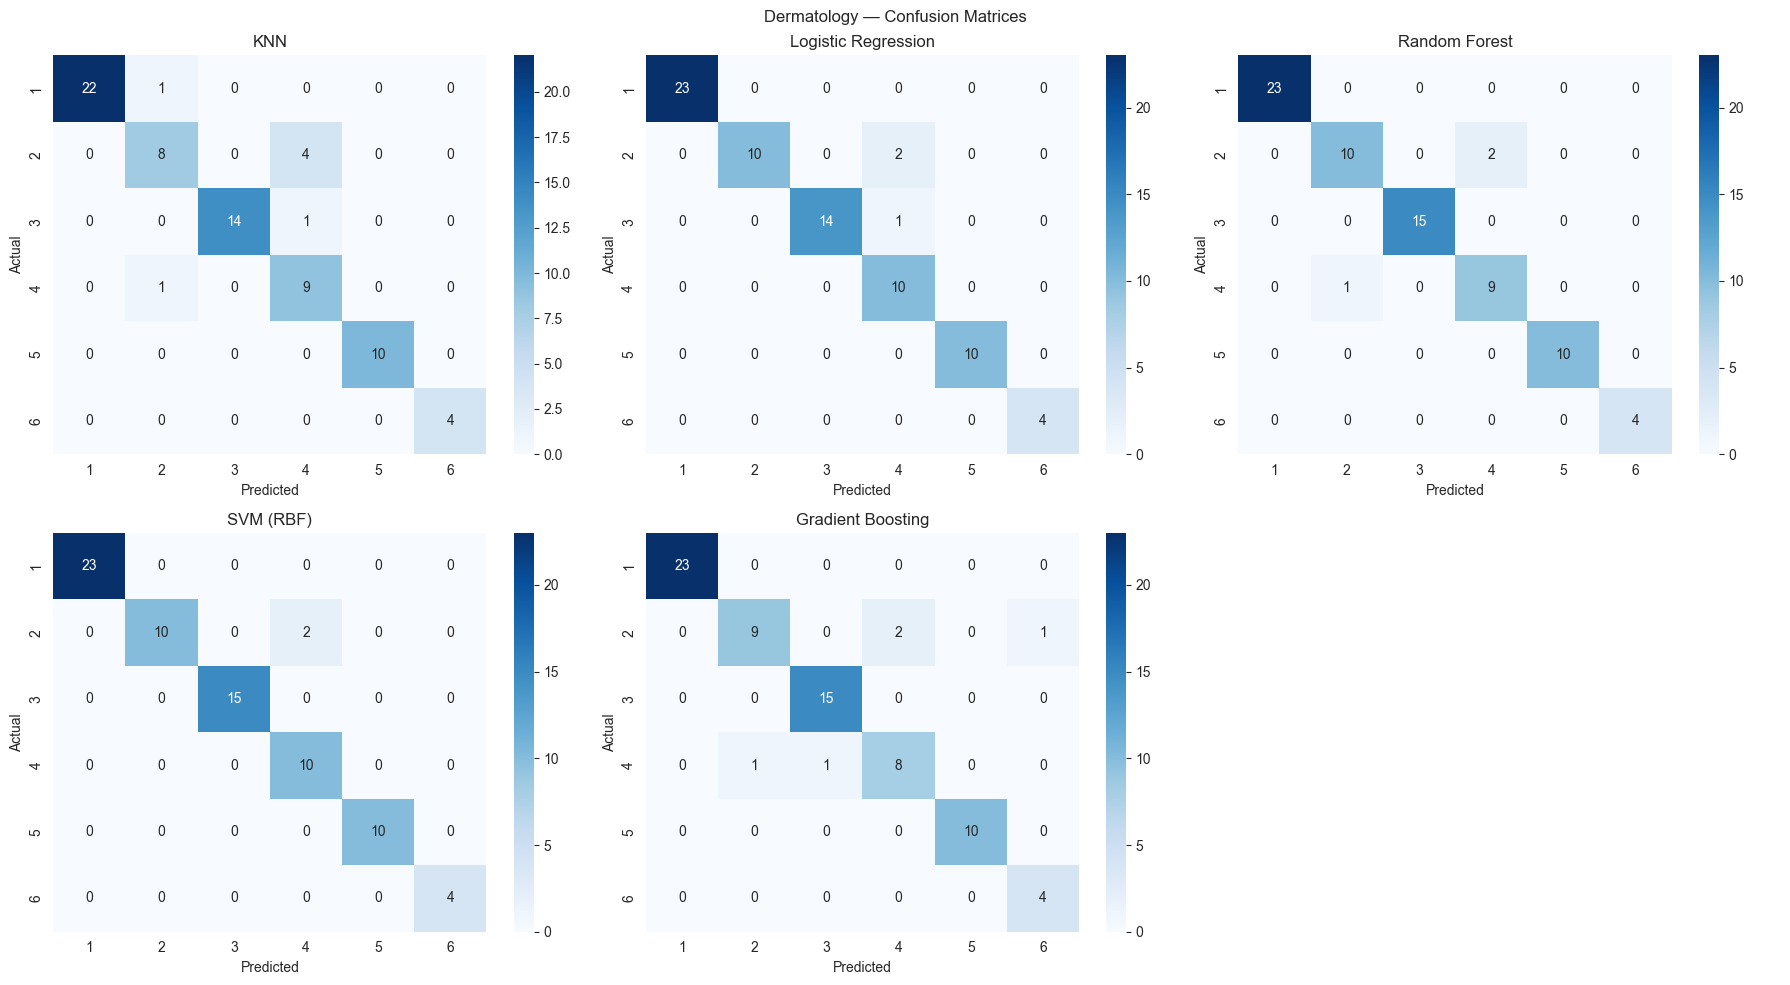

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[len(models):]:
    ax.axis("off")

plt.suptitle("Dermatology — Confusion Matrices")
plt.tight_layout()
plt.show()


### 3.4 ROC Curves and AUC (One-vs-Rest, Multiclass)

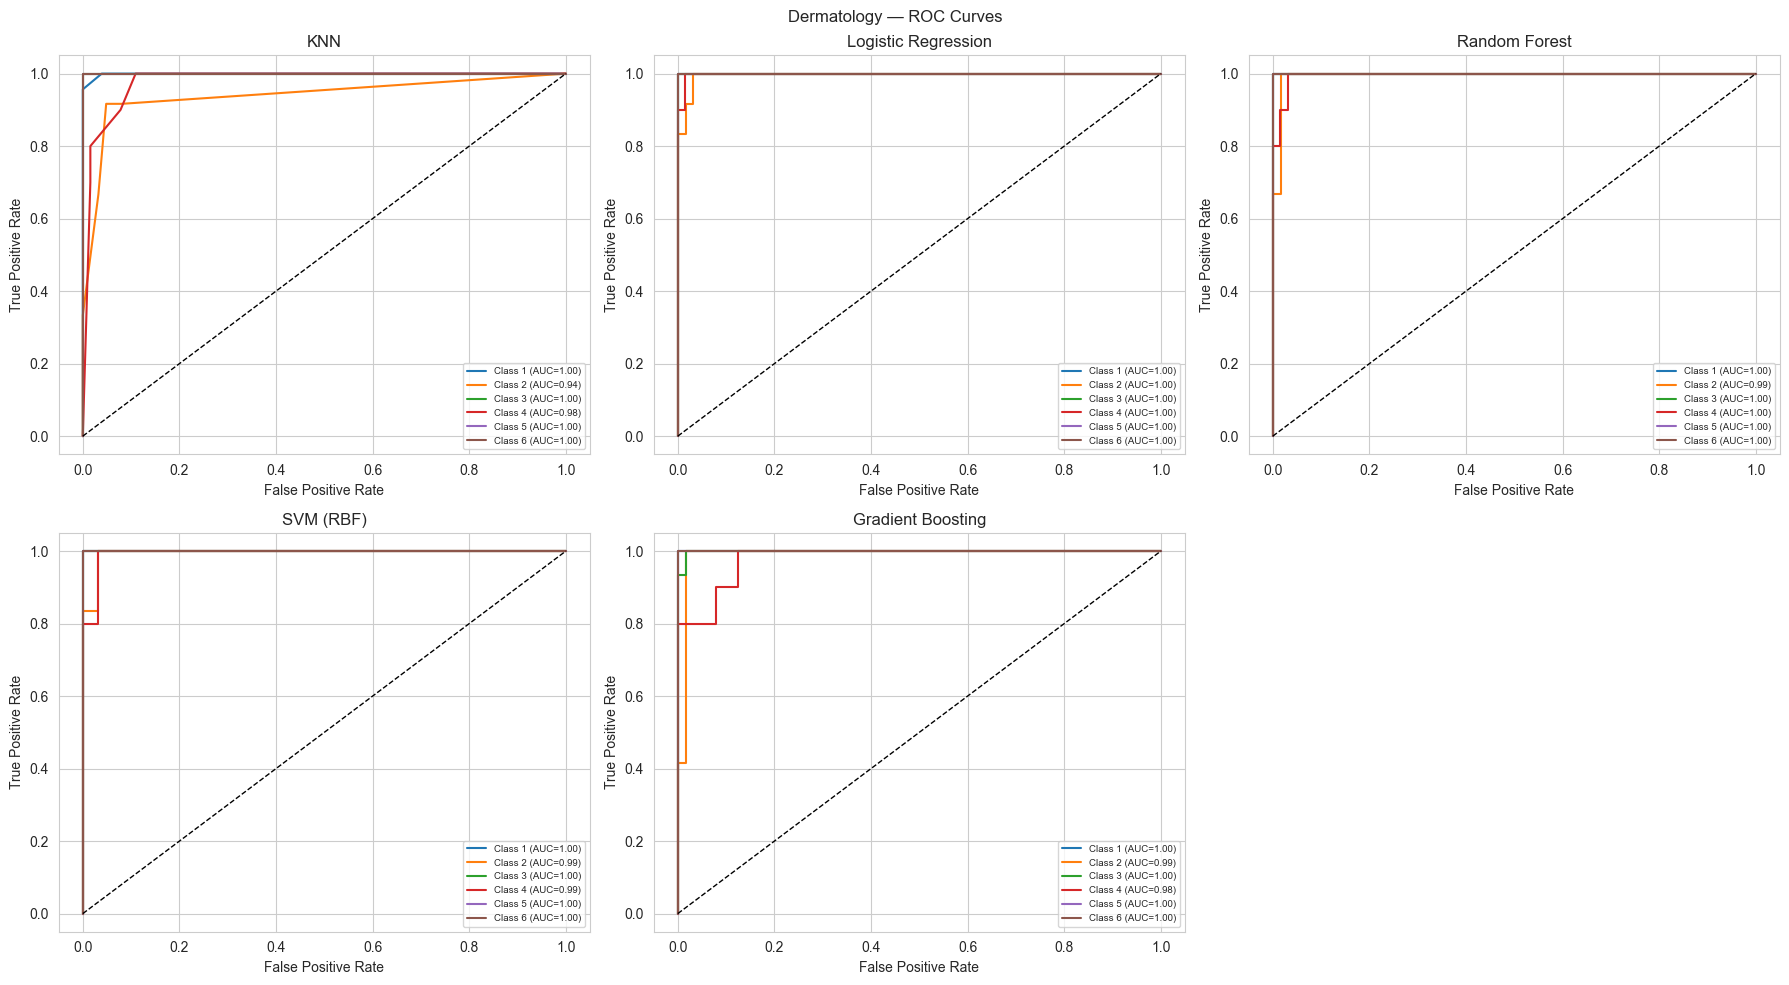

Macro-averaged AUC (OvR) per model:
  KNN: 0.9863
  Logistic Regression: 0.9991
  Random Forest: 0.9983
  SVM (RBF): 0.9981
  Gradient Boosting: 0.9949


In [21]:
classes = np.unique(y)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

auc_scores = {}

for ax, name in zip(axes, models):
    y_score = probabilities[name]
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], label=f"Class {le.classes_[i]} (AUC={roc_auc[i]:.2f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=7)

    macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
    auc_scores[name] = macro_auc

for ax in axes[len(models):]:
    ax.axis("off")

plt.suptitle("Dermatology — ROC Curves")
plt.tight_layout()
plt.show()

print("Macro-averaged AUC (OvR) per model:")
for name, score in auc_scores.items():
    print(f"  {name}: {score:.4f}")


### 3.5 Model Comparison Summary

In [22]:
results_df["AUC (macro, OvR)"] = pd.Series(auc_scores)
results_df.sort_values("F1 (macro)", ascending=False)


,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),"AUC (macro, OvR)"
Model,,,,,,,,
SVM (RBF),0.9730,0.9722,0.9722,0.9697,0.9775,0.9730,0.9730,0.998062
Logistic Regression,0.9595,0.9615,0.9611,0.9574,0.9688,0.9595,0.9606,0.999068
Random Forest,0.9595,0.9545,0.9556,0.9545,0.9607,0.9595,0.9595,0.998323
Gradient Boosting,0.9324,0.9062,0.9250,0.9125,0.9333,0.9324,0.9309,0.994858
KNN,0.9054,0.9071,0.9094,0.9034,0.9193,0.9054,0.9081,0.986262


### 3.6 Interpretation — Dermatology

Fill this in after running the cells above, using the tables/plots as evidence:

- **Best overall model:** which model has the highest Accuracy / macro-F1 / AUC, and by how much?
- **Precision vs. Recall trade-offs:** are there specific classes where a model has high precision but low recall, or vice versa? Cross-check against the confusion matrices — which classes get confused with each other most often?
- **Effect of class imbalance:** compare macro-averaged vs. weighted-averaged metrics — a big gap signals the model is struggling on minority classes.
- **ROC/AUC:** which classes are hardest to separate from the rest (lowest per-class AUC)?
- **Practical recommendation:** for a healthcare diagnosis task, would you prioritize recall (fewer missed diagnoses) over precision, and which model best satisfies that?


---
---
# PART B: Vertebral Dataset
---
---


## Task 1: Data Acquisition and Exploration — Vertebral

### 1.1 Download and Load the Dataset

In [23]:
# pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
vertebral_column = fetch_ucirepo(id=212)

# data (as pandas dataframes)
X_raw = vertebral_column.data.features
y_raw = vertebral_column.data.targets

# metadata
print(vertebral_column.metadata)

# variable information
print(vertebral_column.variables)


{'uci_id': 212, 'name': 'Vertebral Column', 'repository_url': 'https://archive.ics.uci.edu/dataset/212/vertebral+column', 'data_url': 'https://archive.ics.uci.edu/static/public/212/data.csv', 'abstract': 'Data set containing values for six biomechanical features used to classify orthopaedic patients into 3 classes (normal, disk hernia or spondilolysthesis) or 2 classes (normal or abnormal).', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 310, 'num_features': 6, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2005, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C5K89B', 'creators': ['Guilherme Barreto', 'Ajalmar Neto'], 'intro_paper': None, 'additional_info': {'summary': "Biomedical data set built by Dr. Henrique da Mota during a medical residence period in the Group of Applied R

In [24]:
# Combine features and target into a single dataframe so it matches
# the same processing pipeline used for the Dermatology dataset in Part A
df = pd.concat([X_raw, y_raw], axis=1)
df.head()


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia


In [25]:
# Identify the target column automatically (handles slightly different column names
# across dataset versions/sources, e.g. 'class', 'Class', 'target')
possible_targets = [c for c in df.columns if c.strip().lower() in ("class", "target", "diagnosis")]
target_col = possible_targets[0] if possible_targets else df.columns[-1]
print("Detected target column:", target_col)

df = df.rename(columns={target_col: "target"})
print("Shape:", df.shape)
df.head()


Detected target column: class
Shape: (310, 7)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,target
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia


In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   target                    310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


### 1.2 Summary Statistics

In [27]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pelvic_incidence,310.0,NaN,NaN,NaN,60.496653,17.23652,26.147921,46.430294,58.691038,72.877696,129.834041
pelvic_tilt,310.0,NaN,NaN,NaN,17.542822,10.00833,-6.554948,10.667069,16.357689,22.120395,49.431864
lumbar_lordosis_angle,310.0,NaN,NaN,NaN,51.93093,18.554064,14.0,37.0,49.562398,63.0,125.742385
sacral_slope,310.0,NaN,NaN,NaN,42.953831,13.423102,13.366931,33.347122,42.404912,52.695888,121.429566
pelvic_radius,310.0,NaN,NaN,NaN,117.920655,13.317377,70.082575,110.709196,118.268178,125.467674,163.071041
degree_spondylolisthesis,310.0,NaN,NaN,NaN,26.296694,37.559027,-11.058179,1.603727,11.767934,41.287352,418.543082
target,310,3,Spondylolisthesis,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.3 Missing Values, Duplicates, and Outliers

In [28]:
# Some UCI-style datasets encode missing values as '?'
df = df.replace("?", np.nan)

# Try to convert all feature columns to numeric where possible
for col in df.columns:
    if col != "target":
        df[col] = pd.to_numeric(df[col], errors="ignore")

print("Missing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing values per column:
 Series([], dtype: int64)

Number of duplicate rows: 0


/var/folders/5c/8z7vyvz92nv0y0r62jyssfnc0000gn/T/ipykernel_19021/1204433995.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [29]:
# Handle missing values — impute numeric columns with the median
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Drop exact duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {before - df.shape[0]} duplicate rows")

print("\nRemaining missing values:", df.isnull().sum().sum())


Dropped 0 duplicate rows

Remaining missing values: 0


In [30]:
# Outlier detection using the IQR method (reported per feature, not auto-removed —
# tree/margin-based models used later are fairly robust to a few outliers)
feature_cols = [c for c in numeric_cols if c != "target"]

outlier_counts = {}
for col in feature_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_summary = pd.Series(outlier_counts).sort_values(ascending=False)
outlier_summary


pelvic_tilt                 13
pelvic_radius               11
degree_spondylolisthesis    10
pelvic_incidence             3
lumbar_lordosis_angle        1
sacral_slope                 1
dtype: int64

### 1.4 Visualizations

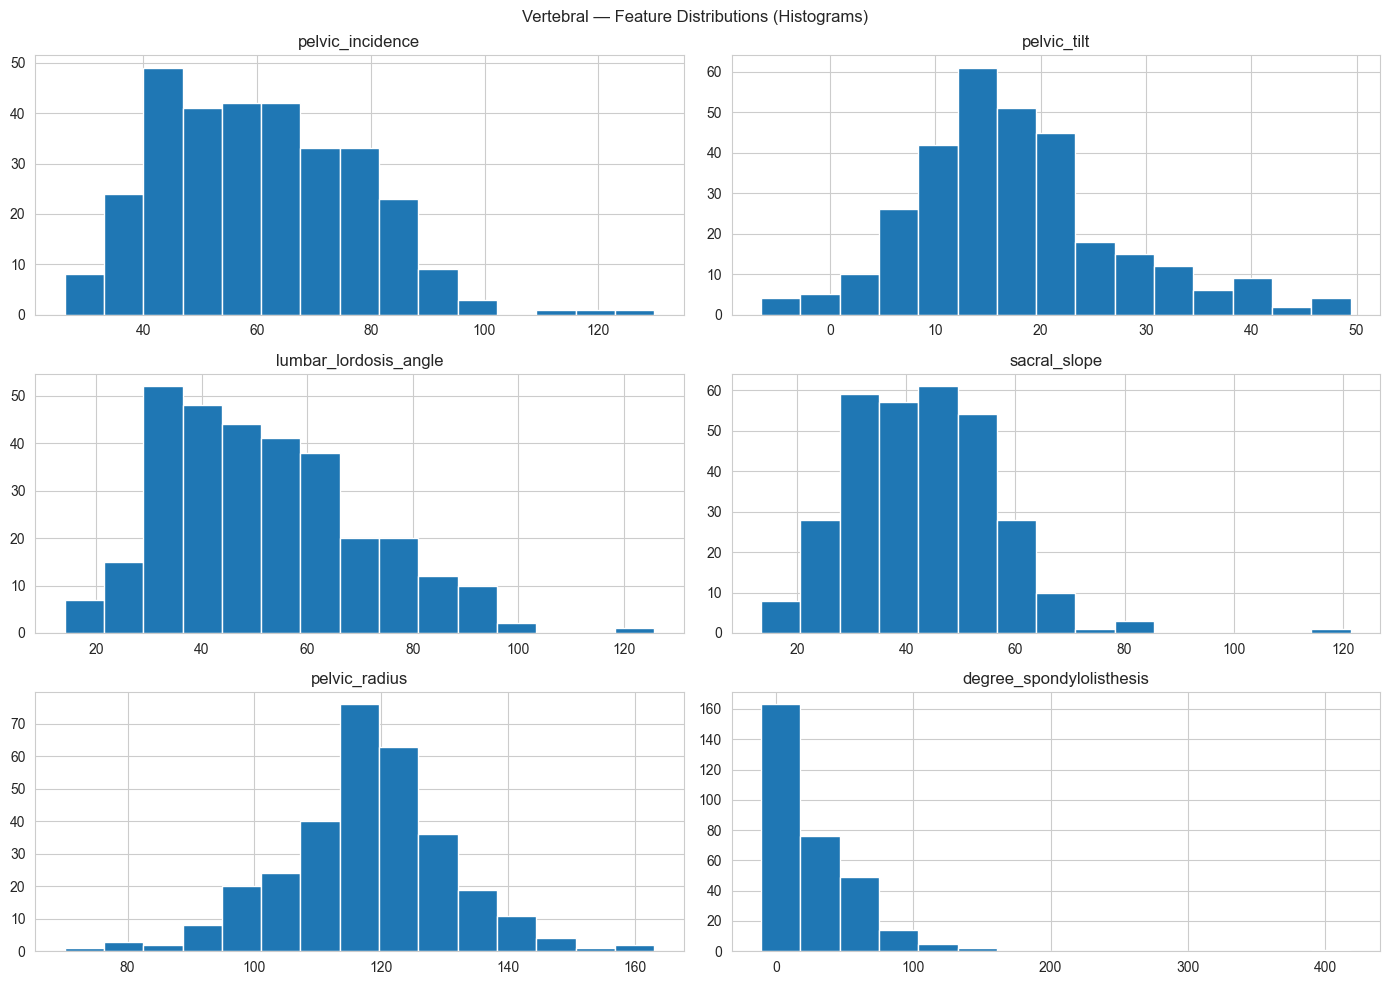

In [31]:
# Histograms for the features (first 12 to keep the plot readable if there are many)
sample_cols = feature_cols[:12]
df[sample_cols].hist(figsize=(14, 10), bins=15)
plt.suptitle("Vertebral — Feature Distributions (Histograms)")
plt.tight_layout()
plt.show()


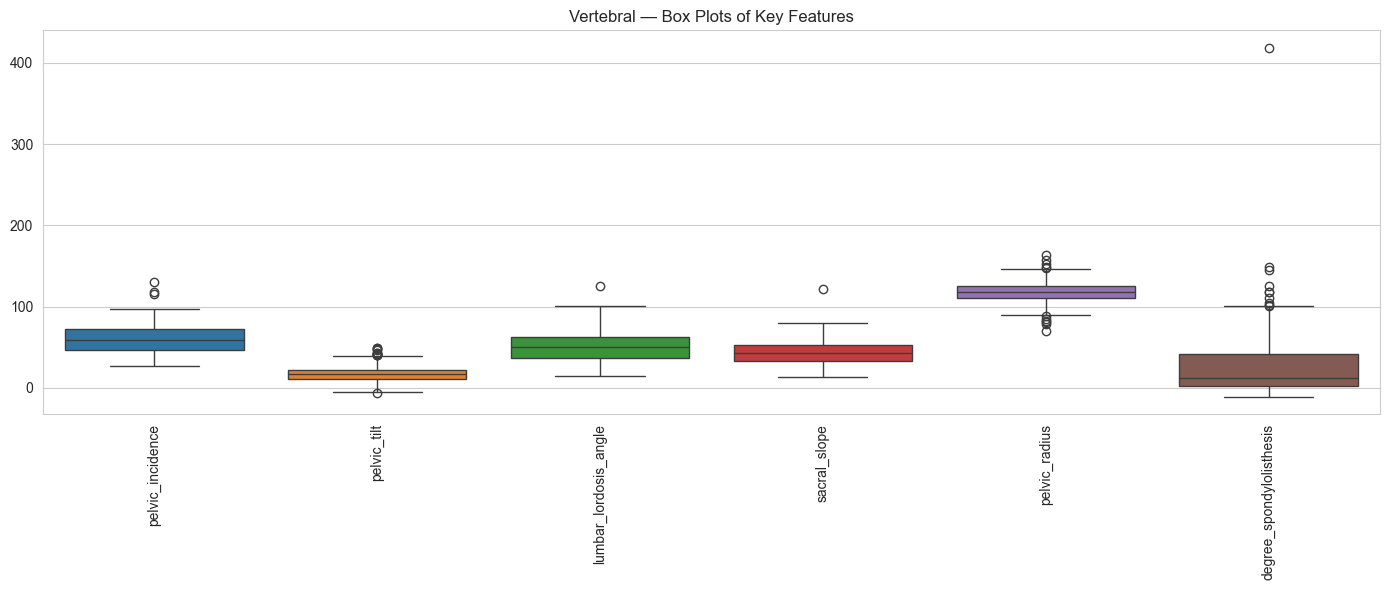

In [32]:
# Box plots for the same features
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[sample_cols])
plt.xticks(rotation=90)
plt.title("Vertebral — Box Plots of Key Features")
plt.tight_layout()
plt.show()


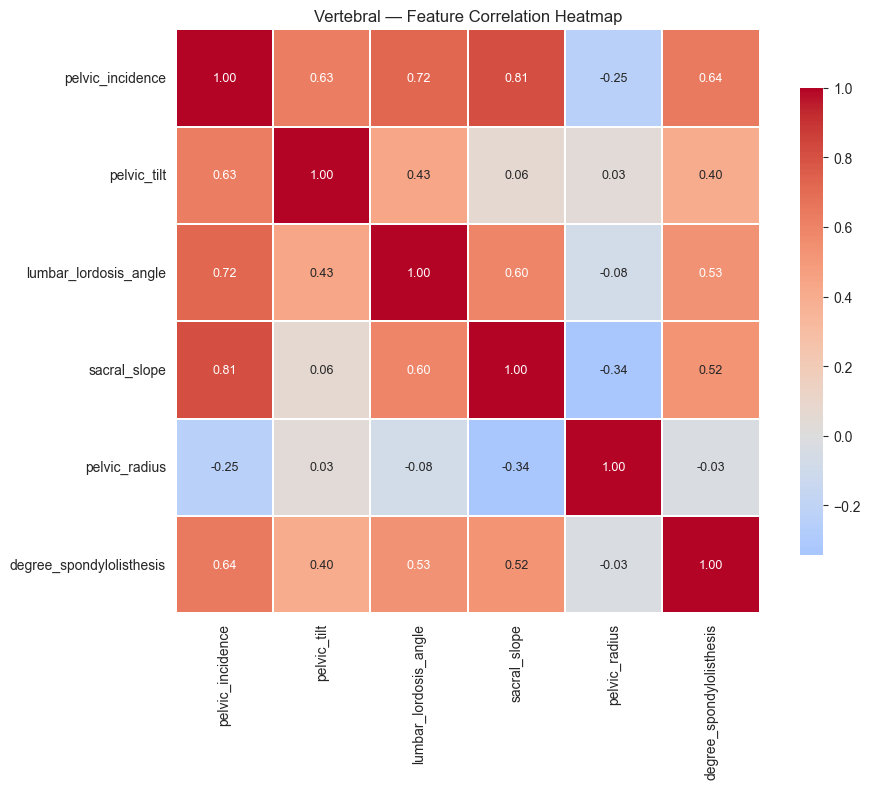

In [33]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3,
            annot=True, fmt=".2f", annot_kws={"size": 9}, cbar_kws={"shrink": 0.8})
plt.title("Vertebral — Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


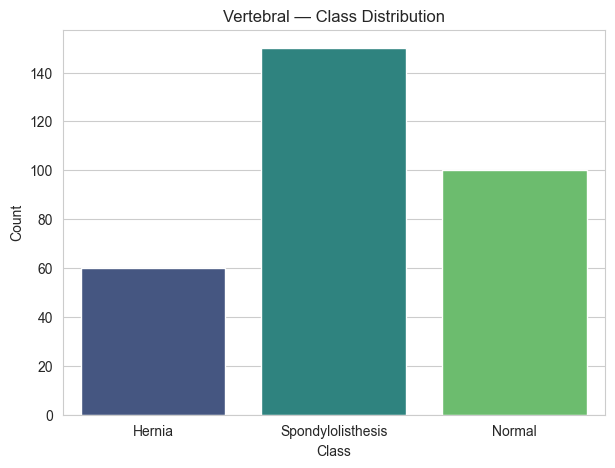

target
Spondylolisthesis    150
Normal               100
Hernia                60
Name: count, dtype: int64


In [34]:
# Class distribution
plt.figure(figsize=(7, 5))
sns.countplot(x="target", data=df, hue="target", palette="viridis", legend=False)
plt.title("Vertebral — Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df["target"].value_counts())


**Discussion — Class Imbalance:**
Check the class distribution plot above. If one or more classes have noticeably fewer samples, the classifier can get biased toward the majority class(es), and plain accuracy can look misleadingly high while minority-class recall stays poor. This is why the split below uses **stratified sampling**, and why Task 3 reports **macro-averaged** metrics alongside weighted ones.

## Task 2: Data Preprocessing

### 2.1 Encode the Target Variable

In [35]:
le = LabelEncoder()
df["target_encoded"] = le.fit_transform(df["target"].astype(str))

print("Classes:", list(le.classes_))
X = df[feature_cols].values
y = df["target_encoded"].values


Classes: ['Hernia', 'Normal', 'Spondylolisthesis']


### 2.2 Train/Test Split (Stratified, 80/20)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class balance:\n", pd.Series(y_train).value_counts(normalize=True).sort_index())
print("\nTest class balance:\n", pd.Series(y_test).value_counts(normalize=True).sort_index())


Train shape: (248, 6) Test shape: (62, 6)
Train class balance:
 0    0.193548
1    0.322581
2    0.483871
Name: proportion, dtype: float64

Test class balance:
 0    0.193548
1    0.322581
2    0.483871
Name: proportion, dtype: float64


### 2.3 Feature Standardization

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean of scaled training features (~0):", np.round(X_train_scaled.mean(), 3))
print("Std of scaled training features (~1):", np.round(X_train_scaled.std(), 3))


Mean of scaled training features (~0): 0.0
Std of scaled training features (~1): 1.0


## Task 3: Model Training and Basic Evaluation

### 3.1 Define and Train Multiple Multiclass Models

In [38]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)
    print(f"Trained: {name}")


Trained: KNN
Trained: Logistic Regression
Trained: Random Forest
Trained: SVM (RBF)
Trained: Gradient Boosting


### 3.2 Accuracy, Precision, Recall, F1-score

In [39]:
results = []
for name in models:
    y_pred = predictions[name]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision (weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df


,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted)
Model,,,,,,,
KNN,0.7097,0.6980,0.6889,0.6815,0.7673,0.7097,0.7237
Logistic Regression,0.8387,0.8015,0.7889,0.7921,0.8411,0.8387,0.8375
Random Forest,0.8387,0.8074,0.8056,0.8041,0.8382,0.8387,0.8361
SVM (RBF),0.8065,0.7856,0.7778,0.7784,0.8218,0.8065,0.8107
Gradient Boosting,0.8710,0.8254,0.8333,0.8273,0.8771,0.8710,0.8725


In [40]:
# Detailed per-class report for each model
for name in models:
    print(f"\n===== {name} — Classification Report =====")
    print(classification_report(y_test, predictions[name], target_names=[str(c) for c in le.classes_], zero_division=0))



===== KNN — Classification Report =====
                   precision    recall  f1-score   support

           Hernia       0.54      0.58      0.56        12
           Normal       0.56      0.75      0.64        20
Spondylolisthesis       1.00      0.73      0.85        30

         accuracy                           0.71        62
        macro avg       0.70      0.69      0.68        62
     weighted avg       0.77      0.71      0.72        62


===== Logistic Regression — Classification Report =====
                   precision    recall  f1-score   support

           Hernia       0.70      0.58      0.64        12
           Normal       0.74      0.85      0.79        20
Spondylolisthesis       0.97      0.93      0.95        30

         accuracy                           0.84        62
        macro avg       0.80      0.79      0.79        62
     weighted avg       0.84      0.84      0.84        62


===== Random Forest — Classification Report =====
                   

### 3.3 Confusion Matrices

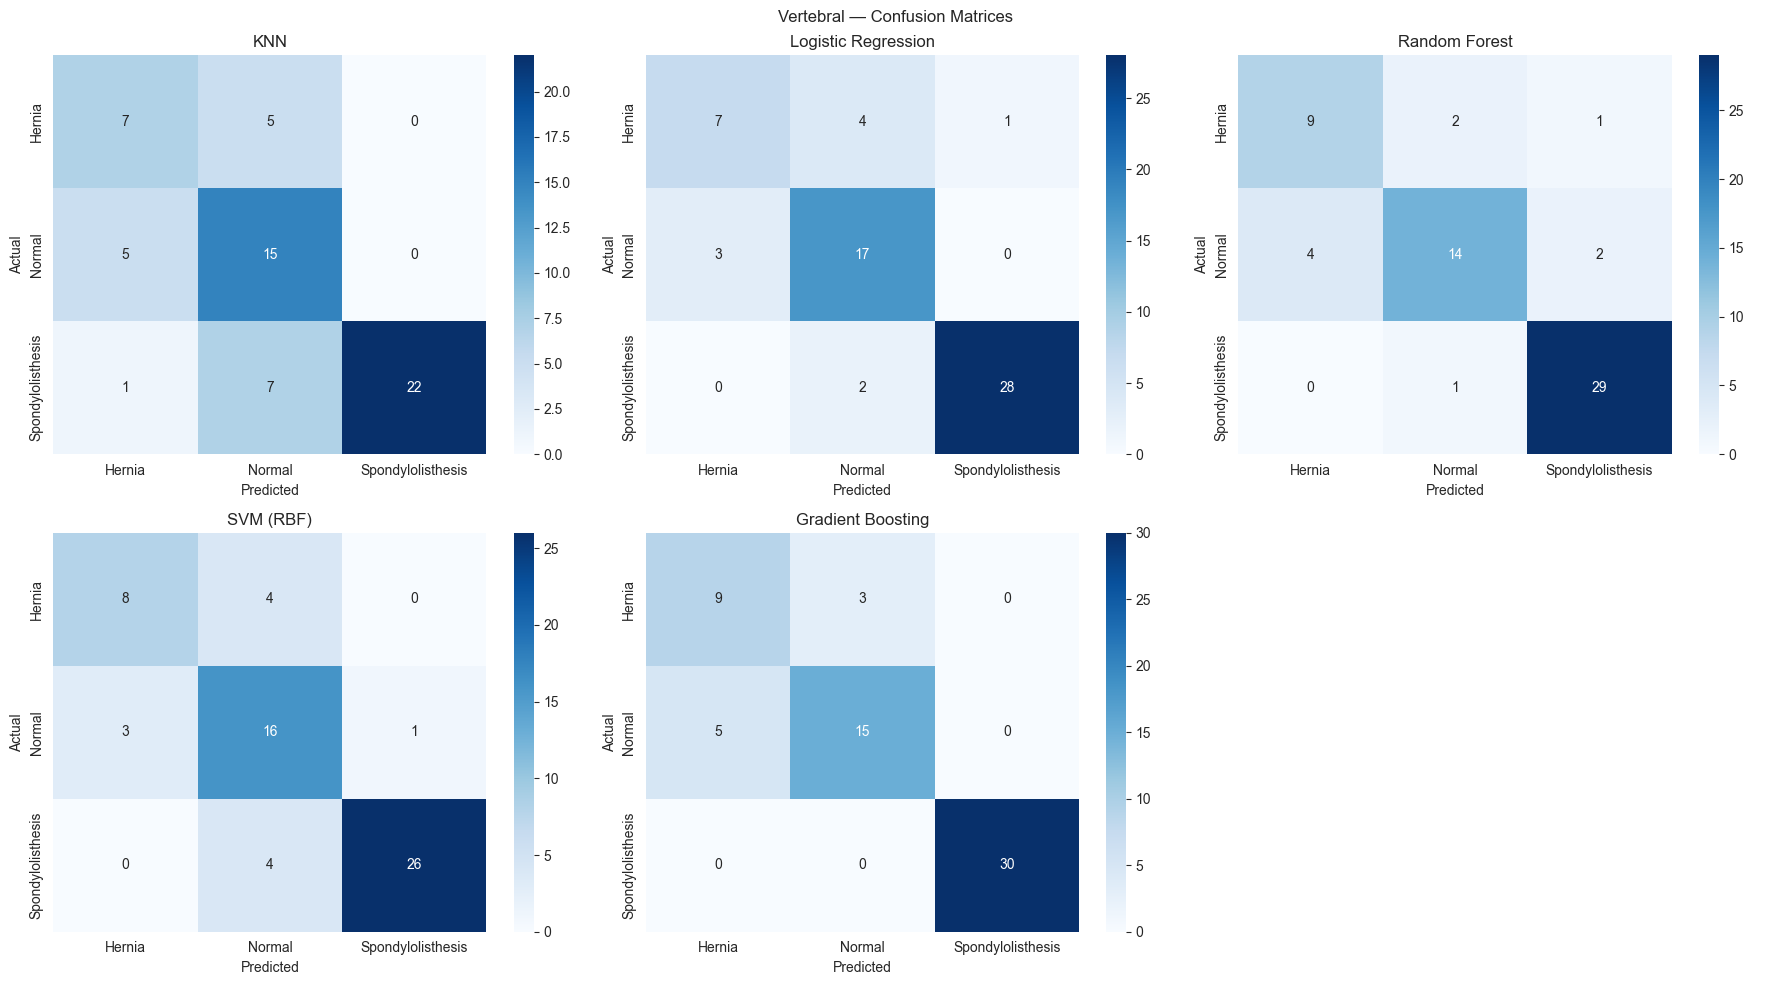

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[len(models):]:
    ax.axis("off")

plt.suptitle("Vertebral — Confusion Matrices")
plt.tight_layout()
plt.show()


### 3.4 ROC Curves and AUC (One-vs-Rest, Multiclass)

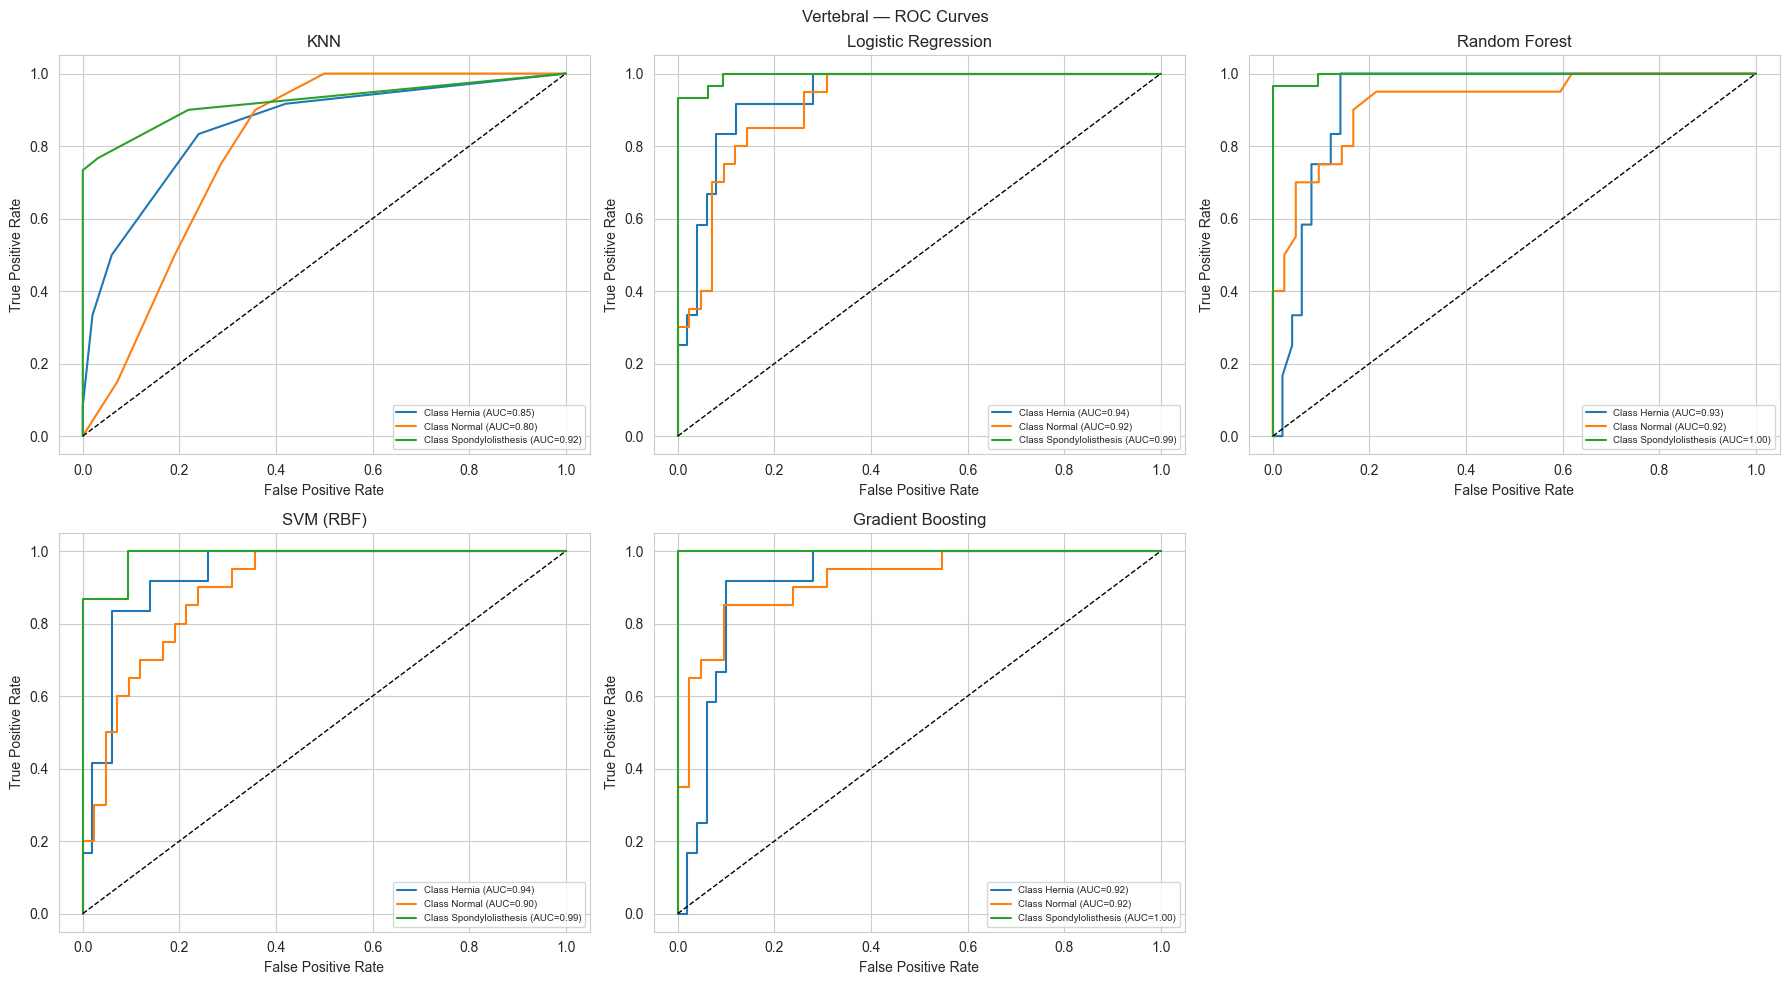

Macro-averaged AUC (OvR) per model:
  KNN: 0.8581
  Logistic Regression: 0.9490
  Random Forest: 0.9488
  SVM (RBF): 0.9402
  Gradient Boosting: 0.9466


In [42]:
classes = np.unique(y)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

auc_scores = {}

for ax, name in zip(axes, models):
    y_score = probabilities[name]
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax.plot(fpr[i], tpr[i], label=f"Class {le.classes_[i]} (AUC={roc_auc[i]:.2f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=7)

    macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
    auc_scores[name] = macro_auc

for ax in axes[len(models):]:
    ax.axis("off")

plt.suptitle("Vertebral — ROC Curves")
plt.tight_layout()
plt.show()

print("Macro-averaged AUC (OvR) per model:")
for name, score in auc_scores.items():
    print(f"  {name}: {score:.4f}")


### 3.5 Model Comparison Summary

In [43]:
results_df["AUC (macro, OvR)"] = pd.Series(auc_scores)
results_df.sort_values("F1 (macro)", ascending=False)


,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),"AUC (macro, OvR)"
Model,,,,,,,,
Gradient Boosting,0.8710,0.8254,0.8333,0.8273,0.8771,0.8710,0.8725,0.946587
Random Forest,0.8387,0.8074,0.8056,0.8041,0.8382,0.8387,0.8361,0.948760
Logistic Regression,0.8387,0.8015,0.7889,0.7921,0.8411,0.8387,0.8375,0.948978
SVM (RBF),0.8065,0.7856,0.7778,0.7784,0.8218,0.8065,0.8107,0.940198
KNN,0.7097,0.6980,0.6889,0.6815,0.7673,0.7097,0.7237,0.858085


### 3.6 Interpretation — Vertebral

Fill this in after running the cells above, using the tables/plots as evidence:

- **Best overall model:** which model has the highest Accuracy / macro-F1 / AUC, and by how much?
- **Precision vs. Recall trade-offs:** are there specific classes where a model has high precision but low recall, or vice versa? Cross-check against the confusion matrices — which classes get confused with each other most often?
- **Effect of class imbalance:** compare macro-averaged vs. weighted-averaged metrics — a big gap signals the model is struggling on minority classes.
- **ROC/AUC:** which classes are hardest to separate from the rest (lowest per-class AUC)?
- **Practical recommendation:** for a healthcare diagnosis task, would you prioritize recall (fewer missed diagnoses) over precision, and which model best satisfies that?
